<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/neural_networks/MLP_Numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Multilayer Perceptron (MLP) from scratch with NumPy

Logistic regression draws a single straight line through the feature space. In this lab we build the simplest model that can draw **curved** boundaries: a neural network with one hidden layer. We write every piece by hand (forward pass, loss, backpropagation, gradient descent) so that nothing in PyTorch will feel like magic in the next lab.

**Contents**

1. The problem: XOR is not linearly separable (proof)
2. Logistic regression fails, and a hand-made feature fixes it
3. The MLP: architecture and forward propagation
4. Activation functions
5. The loss: binary cross-entropy
6. Backpropagation: derivation
7. Implementation: the `SimpleMLP` class
8. Gradient checking
9. Training with mini-batch gradient descent
10. Evaluation: accuracy, decision boundary, what the hidden units learn
11. Experiments: width, learning rate, random restarts, initialisation
12. Summary and exercises

The full theory (with every proof) is in the course notes [`notes/neural_networks/00_neural_networks_mlp`](https://imagra93.github.io/ML-course-labs/notes/neural_networks/00_neural_networks_mlp.html) and [`notes/neural_networks/01_backpropagation`](https://imagra93.github.io/ML-course-labs/notes/neural_networks/01_backpropagation.html). This lab uses the same notation.

**Notation**

| Symbol | Meaning |
|---|---|
| $m$ | number of examples in a batch |
| $n_0 = 2,\; n_1 = 4,\; n_2 = 1$ | widths of the input, hidden and output layers |
| $\mathbf{X} \in \mathbb{R}^{m \times n_0}$ | inputs, **one example per row** |
| $\mathbf{y} \in \{0,1\}^{m \times 1}$ | labels |
| $\mathbf{W}^{[l]} \in \mathbb{R}^{n_{l-1} \times n_l},\; \mathbf{b}^{[l]} \in \mathbb{R}^{1 \times n_l}$ | weights and bias of layer $l$ |
| $\mathbf{Z}^{[l]} = \mathbf{A}^{[l-1]}\mathbf{W}^{[l]} + \mathbf{b}^{[l]}$ | pre-activation of layer $l$ ($\mathbf{A}^{[0]} = \mathbf{X}$) |
| $\mathbf{A}^{[l]} = g(\mathbf{Z}^{[l]})$ | activation of layer $l$; $\mathbf{A}^{[2]} = \hat{\mathbf{y}}$ is the predicted probability |
| $\boldsymbol{\delta}^{[l]} = \partial J / \partial \mathbf{Z}^{[l]}$ | "error" of layer $l$, the quantity backprop propagates |
| $J$ | loss (mean binary cross-entropy) |
| $\alpha$ | learning rate |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(42)

## 1. The problem: XOR is not linearly separable

We sample points $(x_1, x_2) \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and label them

$$
y = \mathbb{1}[x_1 x_2 > 0],
$$

so $y = 1$ in the first and third quadrants and $y = 0$ in the second and fourth. This is the continuous version of the logical **XOR** (more precisely XNOR: the label is 1 when both signs agree).

| $x_1$ | $x_2$ | $y$ |
|---|---|---|
| $+$ | $+$ | 1 |
| $+$ | $-$ | 0 |
| $-$ | $+$ | 0 |
| $-$ | $-$ | 1 |

**Claim.** No line $\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$ separates the classes, not even for the four corner points $(\pm 1, \pm 1)$.

*Proof.* A separating line would need $s(\mathbf{x}) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 > 0$ on the class-1 points and $< 0$ on the class-0 points:

$$
s(1,1) = \theta_0 + \theta_1 + \theta_2 > 0, \qquad s(-1,-1) = \theta_0 - \theta_1 - \theta_2 > 0,
$$
$$
s(1,-1) = \theta_0 + \theta_1 - \theta_2 < 0, \qquad s(-1,1) = \theta_0 - \theta_1 + \theta_2 < 0.
$$

Adding the first two gives $2\theta_0 > 0$. Adding the last two gives $2\theta_0 < 0$. Contradiction. $\blacksquare$

We create a **training set** (used to fit the parameters) and a separate **validation set** (used only to measure how well the model generalises to points it has never seen).

In [2]:
def make_xor(n, rng):
    """n points from N(0, I) with label 1[x1 * x2 > 0]. y has shape (n, 1)."""
    X = rng.normal(size=(n, 2))
    y = (X[:, 0] * X[:, 1] > 0).astype(float).reshape(-1, 1)
    return X, y

X, y = make_xor(1000, rng)          # training set
X_val, y_val = make_xor(500, rng)   # validation set

print("X shape:", X.shape, "  y shape:", y.shape)
print("first rows of X:\n", X[:3].round(3))
print("first labels:", y[:3].ravel())
print(f"fraction of class 1: {y.mean():.3f}  (so always guessing one class gives about 50% accuracy)")

X shape: (1000, 2)   y shape: (1000, 1)
first rows of X:
 [[ 0.305 -1.04 ]
 [ 0.75   0.941]
 [-1.951 -1.302]]
first labels: [0. 1. 1.]
fraction of class 1: 0.526  (so always guessing one class gives about 50% accuracy)


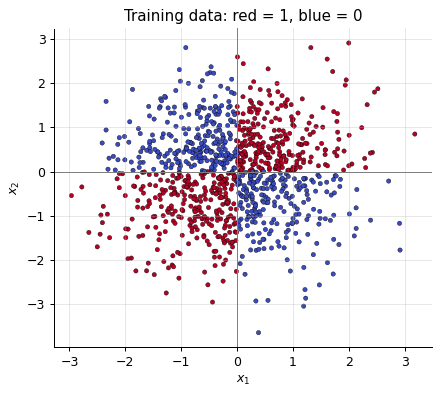

In [3]:
def scatter_classes(ax, X, y, s=12):
    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="coolwarm", s=s, edgecolors="k", linewidths=0.3)
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

fig, ax = plt.subplots(figsize=(5, 4.5))
scatter_classes(ax, X, y)
ax.set_title("Training data: red = 1, blue = 0")
plt.tight_layout(); plt.show()

## 2. Logistic regression fails, and a hand-made feature fixes it

Logistic regression predicts $\hat{y} = \sigma(\theta_0 + \theta_1 x_1 + \theta_2 x_2)$. Its decision boundary $\hat{y} = 0.5$ is the line $\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$, so by section 1 it cannot fit this data. We expect roughly 50% accuracy: no better than guessing.

The helper below draws the predicted probability $\hat{y}(\mathbf{x})$ on a grid (background colour) and the decision boundary $\hat{y} = 0.5$ (black line). We will reuse it for every model.

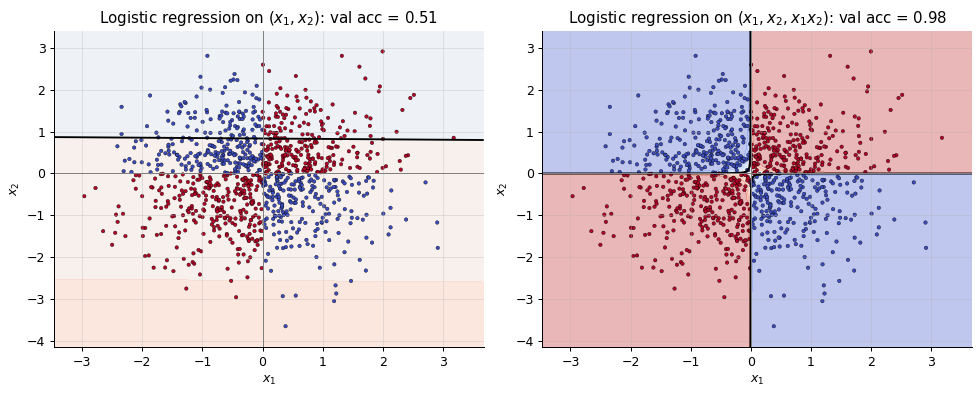

In [4]:
from sklearn.linear_model import LogisticRegression

def plot_boundary(ax, predict_proba, X, y, title=""):
    """Background = predicted P(y=1 | x); black line = decision boundary P = 0.5."""
    x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 250)
    x2 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 250)
    G1, G2 = np.meshgrid(x1, x2)
    P = predict_proba(np.c_[G1.ravel(), G2.ravel()]).reshape(G1.shape)
    ax.contourf(G1, G2, P, levels=np.linspace(0, 1, 11), cmap="coolwarm", alpha=0.35)
    ax.contour(G1, G2, P, levels=[0.5], colors="k", linewidths=1.5)
    scatter_classes(ax, X, y, s=8)
    ax.set_title(title)

logreg = LogisticRegression().fit(X, y.ravel())
acc_lr = logreg.score(X_val, y_val.ravel())

# Same model, but we add the hand-made feature x1 * x2
add_product = lambda X: np.c_[X, X[:, 0] * X[:, 1]]
logreg_prod = LogisticRegression(C=100).fit(add_product(X), y.ravel())
acc_prod = logreg_prod.score(add_product(X_val), y_val.ravel())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_boundary(axes[0], lambda G: logreg.predict_proba(G)[:, 1], X, y,
              f"Logistic regression on $(x_1, x_2)$: val acc = {acc_lr:.2f}")
plot_boundary(axes[1], lambda G: logreg_prod.predict_proba(add_product(G))[:, 1], X, y,
              f"Logistic regression on $(x_1, x_2, x_1x_2)$: val acc = {acc_prod:.2f}")
plt.tight_layout(); plt.show()

**What just happened?** With the extra feature $x_3 = x_1 x_2$ the problem becomes linear: $y = \mathbb{1}[x_3 > 0]$, a plane in $(x_1, x_2, x_3)$ space. The boundary looks curved in the original plane, but the model is still linear in its features.

This is the key idea of neural networks. Designing the right features by hand works for a toy problem, but not for images or text. A neural network **learns the features**: the hidden layer computes new features from the inputs, and the output layer is a logistic regression on those learned features.

## 3. The MLP: architecture and forward propagation

**One neuron is a logistic regression.** A neuron takes a vector $\mathbf{x}$, computes a weighted sum plus a bias, and applies a non-linear function $g$ (the **activation**):

$$
a = g(\mathbf{x}^\top\mathbf{w} + b).
$$

With $g = \sigma$ (the sigmoid) this is exactly logistic regression. Geometrically, each neuron cuts the plane with a line $\mathbf{x}^\top\mathbf{w} + b = 0$ and outputs a value close to 1 on one side and close to 0 on the other.

**A layer is several neurons side by side**, each with its own weight vector. Stacking those vectors as the columns of a matrix $\mathbf{W}^{[1]}$ lets us compute all neurons, for all examples, with one matrix product. Our network has 2 inputs, one hidden layer of 4 neurons and 1 output neuron:

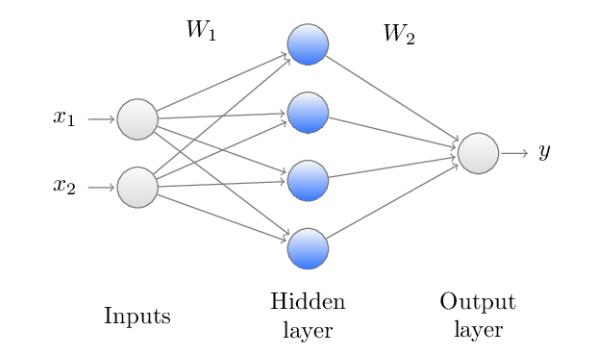

**Forward propagation** for a batch $\mathbf{X}$ of $m$ examples (rows):

$$
\begin{aligned}
\mathbf{Z}^{[1]} &= \mathbf{X}\,\mathbf{W}^{[1]} + \mathbf{b}^{[1]} &&\in \mathbb{R}^{m \times 4} &&\text{(4 weighted sums per example)}\\
\mathbf{A}^{[1]} &= \sigma(\mathbf{Z}^{[1]}) &&\in \mathbb{R}^{m \times 4} &&\text{(the 4 learned features)}\\
\mathbf{Z}^{[2]} &= \mathbf{A}^{[1]}\,\mathbf{W}^{[2]} + \mathbf{b}^{[2]} &&\in \mathbb{R}^{m \times 1} &&\\
\hat{\mathbf{y}} = \mathbf{A}^{[2]} &= \sigma(\mathbf{Z}^{[2]}) &&\in \mathbb{R}^{m \times 1} &&\text{(logistic regression on the features)}
\end{aligned}
$$

In one line: $\hat{\mathbf{y}} = \sigma\big(\sigma(\mathbf{X}\mathbf{W}^{[1]} + \mathbf{b}^{[1]})\,\mathbf{W}^{[2]} + \mathbf{b}^{[2]}\big)$.

| Array | Shape | Entry $(i, j)$ means |
|---|---|---|
| $\mathbf{X}$ | $(m, 2)$ | feature $j$ of example $i$ |
| $\mathbf{W}^{[1]}$ | $(2, 4)$ | weight from input $i$ to hidden neuron $j$ (column $j$ = weights of neuron $j$) |
| $\mathbf{b}^{[1]}$ | $(1, 4)$ | bias of hidden neuron $j$ |
| $\mathbf{Z}^{[1]}, \mathbf{A}^{[1]}$ | $(m, 4)$ | hidden neuron $j$ on example $i$ |
| $\mathbf{W}^{[2]}$ | $(4, 1)$ | weight from hidden neuron $i$ to the output |
| $\mathbf{b}^{[2]}$ | $(1, 1)$ | output bias |
| $\mathbf{Z}^{[2]}, \mathbf{A}^{[2]}$ | $(m, 1)$ | output for example $i$ |

Two practical remarks:
- The bias $\mathbf{b}^{[1]}$ has shape $(1, 4)$ but is added to an $(m, 4)$ matrix. NumPy **broadcasting** copies it to every row, which is exactly "same bias for every example".
- The network has $2 \cdot 4 + 4 + 4 \cdot 1 + 1 = 17$ parameters. In general a layer from $n_{l-1}$ to $n_l$ units has $n_{l-1} n_l + n_l$ parameters.

**Why the activation must be non-linear.** Without $\sigma$ the two layers collapse into one:

$$
(\mathbf{X}\mathbf{W}^{[1]} + \mathbf{b}^{[1]})\mathbf{W}^{[2]} + \mathbf{b}^{[2]} = \mathbf{X}\underbrace{(\mathbf{W}^{[1]}\mathbf{W}^{[2]})}_{\mathbf{W}'} + \underbrace{(\mathbf{b}^{[1]}\mathbf{W}^{[2]} + \mathbf{b}^{[2]})}_{\mathbf{b}'} ,
$$

which is again a linear model, however many layers we stack. The non-linearity is what lets the hidden layer build new features.

**How powerful is this?** The *universal approximation theorem* (Cybenko 1989, Hornik 1991) says that one hidden layer with enough neurons can approximate any continuous function on a bounded region as closely as we want. It says nothing about how many neurons are needed, or whether gradient descent will find the weights. Section 11 explores both questions on our data.

## 4. Activation functions

The three activations you will meet most often:

| Name | $g(z)$ | $g'(z)$ | Range | Where it is used |
|---|---|---|---|---|
| sigmoid | $\sigma(z) = \dfrac{1}{1 + e^{-z}}$ | $\sigma(z)\,(1 - \sigma(z))$ | $(0, 1)$ | output layer for binary classification |
| tanh | $\tanh z = 2\sigma(2z) - 1$ | $1 - \tanh^2 z$ | $(-1, 1)$ | hidden layers (older networks, RNNs) |
| ReLU | $\max(0, z)$ | $1$ if $z > 0$, else $0$ | $[0, \infty)$ | hidden layers (default today) |

**Derivative of the sigmoid (proof).** Write $\sigma(z) = (1 + e^{-z})^{-1}$. By the chain rule,

$$
\sigma'(z) = \frac{e^{-z}}{(1 + e^{-z})^2} = \underbrace{\frac{1}{1 + e^{-z}}}_{\sigma(z)} \cdot \underbrace{\frac{e^{-z}}{1 + e^{-z}}}_{1 - \sigma(z)} . \qquad\blacksquare
$$

This is convenient: the forward pass already computed $\sigma(z)$, so the derivative costs one multiplication.

**Implementation note.** For very negative $z$, `np.exp(-z)` overflows (for example $e^{1000}$). We clip $z$ to $[-500, 500]$, where $\sigma$ is already 0 or 1 to machine precision.

**Your turn** (already filled in): implement `sigmoid` and `sigmoid_derivative`.

In [5]:
def sigmoid(z):
    z = np.clip(z, -500, 500)       # avoid overflow in exp for very large |z|
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1.0 - s)

# Quick sanity checks
print("sigmoid(0)          =", sigmoid(0.0), "  (expected 0.5)")
print("sigmoid(-z)         =", sigmoid(-2.0), "=", 1 - sigmoid(2.0), " (symmetry: 1 - sigmoid(z))")
print("sigmoid'(0)         =", sigmoid_derivative(0.0), "  (the maximum, 1/4)")
print("sigmoid(-1000)      =", sigmoid(-1000.0), "  (no overflow warning)")

sigmoid(0)          = 0.5   (expected 0.5)
sigmoid(-z)         = 0.11920292202211755 = 0.11920292202211769  (symmetry: 1 - sigmoid(z))
sigmoid'(0)         = 0.25   (the maximum, 1/4)
sigmoid(-1000)      = 7.124576406741285e-218   (no overflow warning)


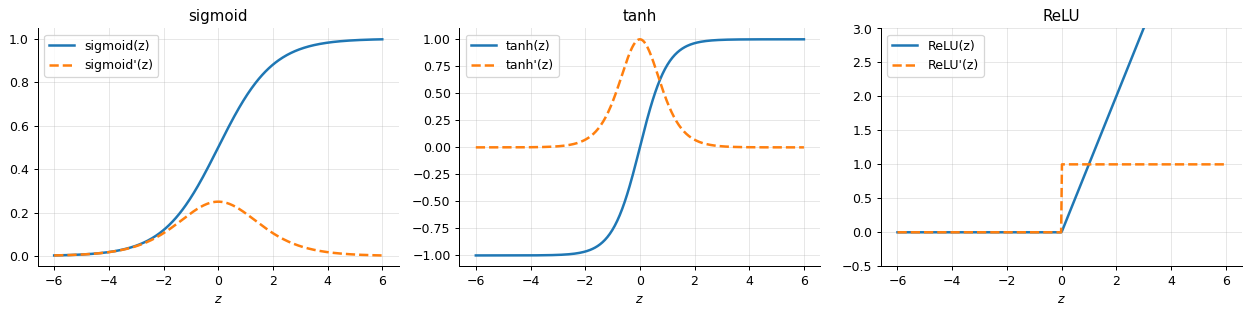

In [6]:
z = np.linspace(-6, 6, 400)
acts = {
    "sigmoid": (sigmoid(z), sigmoid_derivative(z)),
    "tanh":    (np.tanh(z), 1 - np.tanh(z) ** 2),
    "ReLU":    (np.maximum(0, z), (z > 0).astype(float)),
}
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, (name, (g, dg)) in zip(axes, acts.items()):
    ax.plot(z, g, lw=2, label=f"{name}(z)")
    ax.plot(z, dg, "--", lw=2, label=f"{name}'(z)")
    ax.set_xlabel("$z$"); ax.set_title(name); ax.legend()
axes[2].set_ylim(-0.5, 3)
plt.tight_layout(); plt.show()

Things to notice in the plots:
- $\sigma'(z) \le 0.25$ everywhere and is almost 0 when $|z| > 5$. A neuron in that region is **saturated**: its gradient is tiny and it learns very slowly. In a deep network the gradient is multiplied by one such factor per layer, so it can shrink exponentially (the **vanishing gradient** problem).
- $\tanh$ has the same shape as the sigmoid but is centred at 0, with a maximum slope of 1.
- ReLU has slope exactly 1 for $z > 0$, so gradients pass through active units unchanged. It is cheap and is the default choice for hidden layers. Its weak point: a unit with $z < 0$ for every input gets zero gradient forever ("dead ReLU").

In this lab we keep the sigmoid everywhere so the derivation stays short. In the PyTorch lab the hidden layers use ReLU.

## 5. The loss: binary cross-entropy

The output $\hat{y} = A^{[2]}$ is read as the probability $P(y = 1 \mid \mathbf{x})$. So the model says $y \mid \mathbf{x} \sim \text{Bernoulli}(\hat{y})$, which can be written in one formula as

$$
p(y \mid \mathbf{x}) = \hat{y}^{\,y}\,(1 - \hat{y})^{1 - y}, \qquad y \in \{0, 1\}.
$$

**Maximum likelihood** (the same recipe as in the linear and logistic regression notes): with independent examples, maximise $\prod_i p(y^{(i)} \mid \mathbf{x}^{(i)})$, or equivalently minimise minus its log, averaged over the examples:

$$
\boxed{J = -\frac{1}{m}\sum_{i=1}^m \Big[\, y^{(i)} \log \hat{y}^{(i)} + (1 - y^{(i)}) \log\big(1 - \hat{y}^{(i)}\big) \Big]}
$$

This is the **binary cross-entropy** (BCE), also called log loss.

- If $y = 1$ only the first term is active: the loss is $-\log \hat{y}$, which is 0 when $\hat{y} = 1$ and grows without bound as $\hat{y} \to 0$.
- If $y = 0$ the loss is $-\log(1 - \hat{y})$: it punishes confident predictions of 1.
- A model that always outputs $\hat{y} = 0.5$ has loss $\log 2 \approx 0.693$. This is a useful reference: a freshly initialised network should start near this value, and a trained one must go well below it.

$\log 0 = -\infty$, so we clip $\hat{y}$ to $[\varepsilon, 1 - \varepsilon]$ before taking logs.

**Why not the squared error?** Combined with a sigmoid output, the squared error has gradient $(\hat{y} - y)\,\hat{y}(1 - \hat{y})$. When the network is confidently wrong ($\hat{y} \approx 0$ but $y = 1$), the factor $\hat{y}(1 - \hat{y})$ is almost 0 and learning stalls. With BCE this factor cancels (section 6), so the gradient is simply $\hat{y} - y$.

**Your turn** (already filled in): implement `binary_cross_entropy`.

In [7]:
def binary_cross_entropy(y_true, y_prob, eps=1e-12):
    y_prob = np.clip(y_prob, eps, 1 - eps)   # avoid log(0)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

y_demo = np.array([[1.0], [0.0]])
print("perfect predictions        :", binary_cross_entropy(y_demo, np.array([[1.0], [0.0]])))
print("always 0.5                 :", binary_cross_entropy(y_demo, np.array([[0.5], [0.5]])), " = log 2 =", np.log(2))
print("confident and wrong (0.01) :", binary_cross_entropy(y_demo, np.array([[0.01], [0.99]])))

perfect predictions        : 9.999778782803785e-13
always 0.5                 : 0.6931471805599453  = log 2 = 0.6931471805599453
confident and wrong (0.01) : 4.605170185988091


## 6. Backpropagation: derivation

Gradient descent needs the derivative of $J$ with respect to **every** parameter: $\mathbf{W}^{[1]}, \mathbf{b}^{[1]}, \mathbf{W}^{[2]}, \mathbf{b}^{[2]}$. Backpropagation computes them with the chain rule, starting at the loss and moving **backwards** through the layers. Each step reuses the result of the previous one, so the whole backward pass costs about as much as one forward pass.

The computational graph we differentiate:

$$
\mathbf{X} \xrightarrow{\;\mathbf{W}^{[1]},\,\mathbf{b}^{[1]}\;} \mathbf{Z}^{[1]} \xrightarrow{\;\sigma\;} \mathbf{A}^{[1]} \xrightarrow{\;\mathbf{W}^{[2]},\,\mathbf{b}^{[2]}\;} \mathbf{Z}^{[2]} \xrightarrow{\;\sigma\;} \mathbf{A}^{[2]} \xrightarrow{\;\text{BCE}\;} J
$$

We define the **error** of layer $l$ as $\boldsymbol{\delta}^{[l]} = \partial J / \partial \mathbf{Z}^{[l]}$, a matrix with the same shape as $\mathbf{Z}^{[l]}$.

### Step 1: output error $\boldsymbol{\delta}^{[2]}$

Take one example and write $a = A^{[2]}$, $z = Z^{[2]}$ and $\ell = -[y \log a + (1-y)\log(1-a)]$. Then

$$
\frac{\partial \ell}{\partial a} = -\frac{y}{a} + \frac{1 - y}{1 - a} = \frac{a - y}{a(1 - a)},
\qquad
\frac{\partial a}{\partial z} = \sigma'(z) = a(1 - a).
$$

Multiplying, the $a(1-a)$ cancels:

$$
\frac{\partial \ell}{\partial z} = a - y .
$$

$J$ is the **mean** of $\ell$ over the $m$ examples, so each example's derivative gets a factor $1/m$:

$$
\boxed{\boldsymbol{\delta}^{[2]} = \frac{1}{m}\big(\mathbf{A}^{[2]} - \mathbf{y}\big)} \in \mathbb{R}^{m \times 1}.
$$

"Prediction minus label": the same expression as in logistic regression.

### Step 2: gradients of the output layer

Entry $i$ of $\mathbf{Z}^{[2]}$ is $Z^{[2]}_i = \sum_j A^{[1]}_{ij} W^{[2]}_j + b^{[2]}$. Weight $W^{[2]}_j$ appears in every example's $Z^{[2]}_i$, with coefficient $A^{[1]}_{ij}$. The chain rule sums over those examples:

$$
\frac{\partial J}{\partial W^{[2]}_j} = \sum_{i=1}^m \delta^{[2]}_i \, A^{[1]}_{ij}
\quad\Longrightarrow\quad
\boxed{\frac{\partial J}{\partial \mathbf{W}^{[2]}} = \mathbf{A}^{[1]\top}\boldsymbol{\delta}^{[2]}}
\qquad
\boxed{\frac{\partial J}{\partial \mathbf{b}^{[2]}} = \sum_{i=1}^m \delta^{[2]}_i}
$$

The bias is added to every row, so its gradient is the sum of the rows of $\boldsymbol{\delta}^{[2]}$.

### Step 3: propagate the error to the hidden layer

$\mathbf{A}^{[1]}$ influences $J$ only through $\mathbf{Z}^{[2]}$. Hidden unit $j$ feeds the output with weight $W^{[2]}_j$, so

$$
\frac{\partial J}{\partial A^{[1]}_{ij}} = \delta^{[2]}_i\, W^{[2]}_j
\quad\Longrightarrow\quad
\frac{\partial J}{\partial \mathbf{A}^{[1]}} = \boldsymbol{\delta}^{[2]}\,\mathbf{W}^{[2]\top} \in \mathbb{R}^{m \times 4}.
$$

Each entry of $\mathbf{A}^{[1]}$ depends only on the matching entry of $\mathbf{Z}^{[1]}$, through $\sigma$. So we multiply **element-wise** ($\odot$) by $\sigma'$:

$$
\boxed{\boldsymbol{\delta}^{[1]} = \big(\boldsymbol{\delta}^{[2]}\,\mathbf{W}^{[2]\top}\big) \odot \sigma'(\mathbf{Z}^{[1]})} \in \mathbb{R}^{m \times 4}.
$$

In words: the error of a hidden unit is the output error, sent back along the weight that connects them, and scaled by how sensitive the unit was at its current input.

### Step 4: gradients of the hidden layer

Exactly as in Step 2, with $\mathbf{X}$ playing the role of $\mathbf{A}^{[1]}$:

$$
\boxed{\frac{\partial J}{\partial \mathbf{W}^{[1]}} = \mathbf{X}^\top\boldsymbol{\delta}^{[1]}}
\qquad
\boxed{\frac{\partial J}{\partial \mathbf{b}^{[1]}} = \sum_{i=1}^m \boldsymbol{\delta}^{[1]}_{i,:}}
$$

### Summary and shape check

| Quantity | Formula | Shape |
|---|---|---|
| $\boldsymbol{\delta}^{[2]}$ | $\frac{1}{m}(\mathbf{A}^{[2]} - \mathbf{y})$ | $(m, 1)$ |
| $\partial J / \partial \mathbf{W}^{[2]}$ | $\mathbf{A}^{[1]\top}\boldsymbol{\delta}^{[2]}$ | $(4, m)(m, 1) = (4, 1)$ |
| $\partial J / \partial \mathbf{b}^{[2]}$ | sum of rows of $\boldsymbol{\delta}^{[2]}$ | $(1, 1)$ |
| $\boldsymbol{\delta}^{[1]}$ | $(\boldsymbol{\delta}^{[2]}\mathbf{W}^{[2]\top}) \odot \sigma'(\mathbf{Z}^{[1]})$ | $(m, 1)(1, 4) = (m, 4)$ |
| $\partial J / \partial \mathbf{W}^{[1]}$ | $\mathbf{X}^\top\boldsymbol{\delta}^{[1]}$ | $(2, m)(m, 4) = (2, 4)$ |
| $\partial J / \partial \mathbf{b}^{[1]}$ | sum of rows of $\boldsymbol{\delta}^{[1]}$ | $(1, 4)$ |

**The shape rule.** The gradient with respect to a parameter always has the same shape as the parameter. If you forget where a transpose goes, write down the shapes and there is only one way to make them fit.

**The general pattern.** For any number of layers, with activation $g$:

$$
\boldsymbol{\delta}^{[l]} = \big(\boldsymbol{\delta}^{[l+1]}\,\mathbf{W}^{[l+1]\top}\big) \odot g'(\mathbf{Z}^{[l]}),
\qquad
\frac{\partial J}{\partial \mathbf{W}^{[l]}} = \mathbf{A}^{[l-1]\top}\boldsymbol{\delta}^{[l]},
\qquad
\frac{\partial J}{\partial \mathbf{b}^{[l]}} = \textstyle\sum_i \boldsymbol{\delta}^{[l]}_{i,:}.
$$

**Why the $\frac{1}{m}$ matters.** Because $J$ is a mean, the gradient does not grow with the batch size. The same learning rate then works for batches of 16 or of 1000.

### Gradient descent

After the backward pass, every parameter takes a step against its gradient:

$$
\mathbf{W}^{[l]} \leftarrow \mathbf{W}^{[l]} - \alpha\,\frac{\partial J}{\partial \mathbf{W}^{[l]}},
\qquad
\mathbf{b}^{[l]} \leftarrow \mathbf{b}^{[l]} - \alpha\,\frac{\partial J}{\partial \mathbf{b}^{[l]}},
\qquad l = 1, 2.
$$

One training step is therefore: **forward pass → loss → backward pass → update**.

## 7. Implementation: the `SimpleMLP` class

The class keeps the parameters and the intermediate results of the forward pass (the **cache**: $\mathbf{Z}^{[1]}, \mathbf{A}^{[1]}, \mathbf{Z}^{[2]}, \mathbf{A}^{[2]}$), because the backward pass needs them.

- **`__init__`**: random weights and zero biases. Random weights **break the symmetry** between hidden units: if they all started equal, they would receive equal gradients and stay equal forever (we check this in section 11).
- **`forward`**: the four equations of section 3.
- **`compute_gradients`**: the backward pass of section 6.
- **`update_parameters`**: one gradient descent step.
- **`train`**: the mini-batch loop of section 9.

The lines that were left blank in the original lab (`forward` and `update_parameters`) are filled in and marked with `# <-`.

In [8]:
class SimpleMLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.3, init="random", seed=0):
        """
        One-hidden-layer MLP with sigmoid activations, trained with mini-batch gradient descent.

        Parameters
            input_size, hidden_size, output_size : layer widths n0, n1, n2
            learning_rate : step size alpha
            init          : "random" (standard normal weights) or "zeros" (to show the symmetry problem)
            seed          : seed of the random generator (initialisation and shuffling)
        """
        self.rng = np.random.default_rng(seed)
        if init == "random":
            self.weights1 = self.rng.normal(size=(input_size, hidden_size))    # W1: (n0, n1)
            self.weights2 = self.rng.normal(size=(hidden_size, output_size))   # W2: (n1, n2)
        elif init == "zeros":
            self.weights1 = np.zeros((input_size, hidden_size))
            self.weights2 = np.zeros((hidden_size, output_size))
        else:
            raise ValueError(init)
        self.bias1 = np.zeros((1, hidden_size))                                # b1: (1, n1)
        self.bias2 = np.zeros((1, output_size))                                # b2: (1, n2)
        self.learning_rate = learning_rate
        self.dW1 = self.db1 = self.dW2 = self.db2 = None

    def forward(self, X, verbose=False):
        """
        Forward pass. X has shape (m, n0); returns A2 = predicted probabilities, shape (m, n2).
            Z1 = X W1 + b1,   A1 = sigmoid(Z1)
            Z2 = A1 W2 + b2,  A2 = sigmoid(Z2)
        """
        self.Z1 = X @ self.weights1 + self.bias1        # <- (m, n1)
        self.A1 = sigmoid(self.Z1)                      # <- (m, n1)
        self.Z2 = self.A1 @ self.weights2 + self.bias2  # <- (m, n2)
        self.A2 = sigmoid(self.Z2)                      # <- (m, n2)
        if verbose:
            print("Z1/A1 shape:", self.Z1.shape)
            print("Z2/A2 shape:", self.Z2.shape)
        return self.A2

    def compute_gradients(self, X, y, verbose=False):
        """
        Backward pass. Must be called right after forward(X), because it uses the cache.
            delta2 = (A2 - y) / m
            dW2 = A1^T delta2,            db2 = sum of rows of delta2
            delta1 = (delta2 W2^T) * sigmoid'(Z1)
            dW1 = X^T delta1,             db1 = sum of rows of delta1
        """
        m = X.shape[0]
        delta2 = (self.A2 - y) / m                                  # (m, n2)
        self.dW2 = self.A1.T @ delta2                               # (n1, n2)
        self.db2 = delta2.sum(axis=0, keepdims=True)                # (1, n2)

        dA1 = delta2 @ self.weights2.T                              # (m, n1)
        delta1 = dA1 * sigmoid_derivative(self.Z1)                  # (m, n1), element-wise
        self.dW1 = X.T @ delta1                                     # (n0, n1)
        self.db1 = delta1.sum(axis=0, keepdims=True)                # (1, n1)

        if verbose:
            for name, arr in [("delta2", delta2), ("dW2", self.dW2), ("db2", self.db2), ("dA1", dA1),
                              ("delta1", delta1), ("dW1", self.dW1), ("db1", self.db1)]:
                print(f"{name:>6} shape: {arr.shape}")

    def update_parameters(self):
        """Gradient descent step: theta <- theta - alpha * dJ/dtheta."""
        self.weights1 -= self.learning_rate * self.dW1  # <-
        self.bias1    -= self.learning_rate * self.db1  # <-
        self.weights2 -= self.learning_rate * self.dW2  # <-
        self.bias2    -= self.learning_rate * self.db2  # <-

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X, threshold=0.5):
        return (self.forward(X) >= threshold).astype(float)

    def train(self, X, y, epochs=2000, batch_size=32, X_val=None, y_val=None, print_every=None):
        """
        Mini-batch gradient descent. Each epoch shuffles the data and visits every example once.
        Returns a dict with the training (and validation) loss after every epoch.
        """
        m = X.shape[0]
        history = {"train": [], "val": []}
        for epoch in range(epochs):
            perm = self.rng.permutation(m)                  # new random order every epoch
            X_shuf, y_shuf = X[perm], y[perm]
            for start in range(0, m, batch_size):
                X_batch = X_shuf[start:start + batch_size]
                y_batch = y_shuf[start:start + batch_size]
                self.forward(X_batch)                       # 1. forward pass (fills the cache)
                self.compute_gradients(X_batch, y_batch)    # 2. backward pass
                self.update_parameters()                    # 3. gradient descent step
            history["train"].append(binary_cross_entropy(y, self.forward(X)))
            if X_val is not None:
                history["val"].append(binary_cross_entropy(y_val, self.forward(X_val)))
            if print_every and (epoch % print_every == 0 or epoch == epochs - 1):
                msg = f"epoch {epoch:5d}   train loss {history['train'][-1]:.4f}"
                if X_val is not None:
                    msg += f"   val loss {history['val'][-1]:.4f}"
                print(msg)
        return history

### Testing the forward pass

A single example must still be a **2-D array** of shape $(1, 2)$: one row, two features. With a batch of two examples, $\mathbf{Z}^{[1]}$ and $\mathbf{A}^{[1]}$ must have shape $(2, 4)$ and the output $(2, 1)$.

In [9]:
mlp = SimpleMLP(input_size=2, hidden_size=4, output_size=1, learning_rate=0.3, seed=0)

one = np.array([[0.5, -0.5]])
print("one example, shape", one.shape)
print("prediction:", mlp.forward(one, verbose=True).ravel(), "\n")

two = np.array([[0.5, -0.5], [1.0, -1.0]])
print("two examples, shape", two.shape)
print("predictions:", mlp.forward(two, verbose=True).ravel())

one example, shape (1, 2)
Z1/A1 shape: (1, 4)
Z2/A2 shape: (1, 1)
prediction: [0.22995439] 

two examples, shape (2, 2)
Z1/A1 shape: (2, 4)
Z2/A2 shape: (2, 1)
predictions: [0.22995439 0.24172957]


### Testing the backward pass

Each gradient must have the shape of its parameter, **whatever the batch size**: $\partial J / \partial \mathbf{W}^{[1]}$ is $(2, 4)$ like $\mathbf{W}^{[1]}$, and so on. Only the $\boldsymbol{\delta}$'s carry the batch dimension $m$.

In [10]:
for batch in [np.array([[0.5, -0.5]]), np.array([[0.5, -0.5], [1.0, 1.0], [-1.0, 0.3]])]:
    y_batch = (batch[:, :1] * batch[:, 1:] > 0).astype(float)
    print(f"--- batch of m = {len(batch)}")
    mlp.forward(batch)
    mlp.compute_gradients(batch, y_batch, verbose=True)

--- batch of m = 1
delta2 shape: (1, 1)
   dW2 shape: (4, 1)
   db2 shape: (1, 1)
   dA1 shape: (1, 4)
delta1 shape: (1, 4)
   dW1 shape: (2, 4)
   db1 shape: (1, 4)
--- batch of m = 3
delta2 shape: (3, 1)
   dW2 shape: (4, 1)
   db2 shape: (1, 1)
   dA1 shape: (3, 4)
delta1 shape: (3, 4)
   dW1 shape: (2, 4)
   db1 shape: (1, 4)


## 8. Gradient checking

Correct shapes do not guarantee correct values. A classic way to test a backward pass is to compare it with a **numerical** derivative. For each parameter entry $\theta$, the central difference

$$
\frac{\partial J}{\partial \theta} \approx \frac{J(\theta + \varepsilon) - J(\theta - \varepsilon)}{2\varepsilon}
$$

has an error of order $\varepsilon^2$ (the first-order terms of the two Taylor expansions cancel). We compare it with the backprop gradient using the relative error

$$
\text{rel. error} = \frac{\lVert \mathbf{g}_{\text{backprop}} - \mathbf{g}_{\text{numeric}} \rVert}{\lVert \mathbf{g}_{\text{backprop}} \rVert + \lVert \mathbf{g}_{\text{numeric}} \rVert}.
$$

Rule of thumb: below $10^{-7}$ is correct, around $10^{-4}$ is suspicious, above $10^{-2}$ means a bug. Numerical gradients need two forward passes **per parameter**, which is far too slow for training but fine as a one-off test.

In [11]:
def numerical_gradient(model, X, y, param_name, eps=1e-5):
    P = getattr(model, param_name)
    grad = np.zeros_like(P)
    for idx in np.ndindex(P.shape):
        old = P[idx]
        P[idx] = old + eps; J_plus = binary_cross_entropy(y, model.forward(X))
        P[idx] = old - eps; J_minus = binary_cross_entropy(y, model.forward(X))
        P[idx] = old
        grad[idx] = (J_plus - J_minus) / (2 * eps)
    return grad

check = SimpleMLP(2, 4, 1, seed=1)
Xc, yc = X[:20], y[:20]
check.forward(Xc); check.compute_gradients(Xc, yc)
for pname, gname in [("weights1", "dW1"), ("bias1", "db1"), ("weights2", "dW2"), ("bias2", "db2")]:
    g_bp, g_num = getattr(check, gname), numerical_gradient(check, Xc, yc, pname)
    rel = np.linalg.norm(g_bp - g_num) / (np.linalg.norm(g_bp) + np.linalg.norm(g_num))
    print(f"{pname:>8}: relative error = {rel:.2e}")

weights1: relative error = 4.03e-10
   bias1: relative error = 6.25e-10
weights2: relative error = 8.05e-11
   bias2: relative error = 2.75e-11


## 9. Training with mini-batch gradient descent

Vocabulary:
- **Batch (mini-batch)**: the subset of examples used for one gradient step, here 32.
- **Iteration**: one forward pass, backward pass and update on one batch.
- **Epoch**: one full pass over the training set. With $1000$ examples and batches of 32 an epoch has $\lceil 1000/32 \rceil = 32$ iterations.

Why mini-batches? The gradient on 32 random examples is a noisy but **unbiased** estimate of the full gradient, at about $1/30$ of the cost. Many cheap noisy steps usually beat a few exact expensive ones. We reshuffle the data at every epoch, so the batches are different each time.

We train for 2000 epochs with learning rate $\alpha = 0.3$ and track the loss on both sets.

In [12]:
mlp = SimpleMLP(input_size=2, hidden_size=4, output_size=1, learning_rate=0.3, seed=0)
history = mlp.train(X, y, epochs=2000, batch_size=32, X_val=X_val, y_val=y_val, print_every=200)

epoch     0   train loss 0.6906   val loss 0.6925


epoch   200   train loss 0.1575   val loss 0.1787


epoch   400   train loss 0.1289   val loss 0.1505


epoch   600   train loss 0.1149   val loss 0.1363


epoch   800   train loss 0.1074   val loss 0.1293


...

epoch  1200   train loss 0.0973   val loss 0.1213


epoch  1400   train loss 0.0930   val loss 0.1165


epoch  1600   train loss 0.0928   val loss 0.1186


epoch  1800   train loss 0.0839   val loss 0.1029


epoch  1999   train loss 0.0827   val loss 0.1005


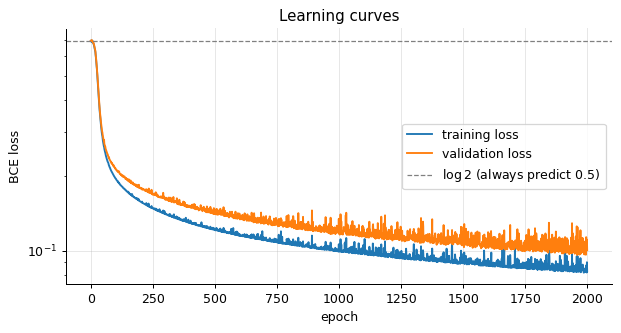

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(history["train"], label="training loss")
ax.plot(history["val"], label="validation loss")
ax.axhline(np.log(2), color="gray", ls="--", lw=1, label=r"$\log 2$ (always predict 0.5)")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("BCE loss"); ax.legend()
ax.set_title("Learning curves")
plt.tight_layout(); plt.show()

**Reading the learning curves.**
- Both losses drop well below $\log 2$: the network has learned something real.
- The curve is not as smooth as in linear regression. Part of the wiggle is mini-batch noise: every step uses a different random batch. Small upward spikes also appear late in training. By then the weights are large and the network is very confident, so a step that moves the boundary slightly flips a few points and they cost a lot of loss.
- The loss can also have **plateaus**, like the flat start of this curve. A plateau is a stretch where the loss barely moves, followed by a sudden drop. The loss of a neural network is **not convex**, and gradient descent can spend a long time near saddle points before finding a way down.
- The validation loss stays close to the training loss, so the model is not overfitting. A validation loss that goes up while the training loss keeps falling would be the sign of overfitting.

## 10. Evaluation: accuracy, decision boundary, what the hidden units learn

**Accuracy** is the fraction of correct predictions after thresholding at 0.5. We report it on the validation set, because accuracy on the training set is optimistic.

model                           val accuracy
logistic regression (x1, x2)           0.510
MLP, 4 hidden units                    0.982    (train accuracy 0.983)


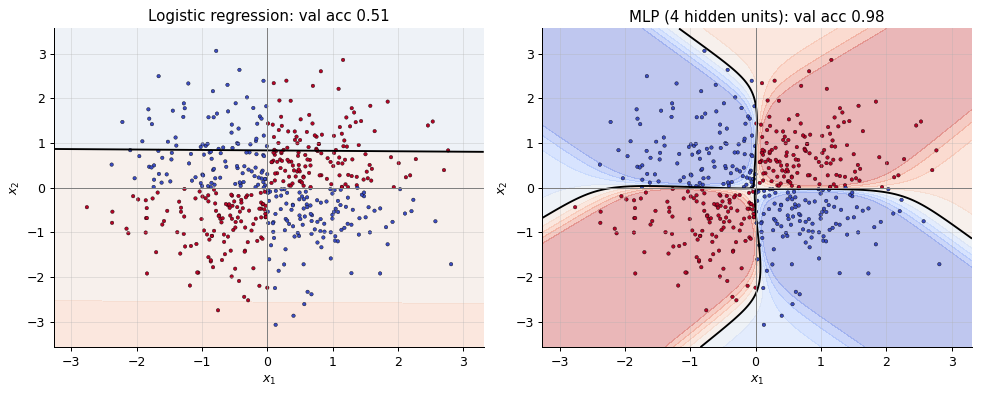

In [14]:
acc_train = np.mean(mlp.predict(X) == y)
acc_val = np.mean(mlp.predict(X_val) == y_val)
print(f"{'model':<32}{'val accuracy':>12}")
print(f"{'logistic regression (x1, x2)':<32}{acc_lr:>12.3f}")
print(f"{'MLP, 4 hidden units':<32}{acc_val:>12.3f}    (train accuracy {acc_train:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_boundary(axes[0], lambda G: logreg.predict_proba(G)[:, 1], X_val, y_val, f"Logistic regression: val acc {acc_lr:.2f}")
plot_boundary(axes[1], mlp.predict_proba, X_val, y_val, f"MLP (4 hidden units): val acc {acc_val:.2f}")
plt.tight_layout(); plt.show()

**What did the hidden layer learn?** Each hidden unit $j$ is a small logistic regression, $A^{[1]}_j = \sigma(x_1 W^{[1]}_{1j} + x_2 W^{[1]}_{2j} + b^{[1]}_j)$. It is close to 1 on one side of the line $x_1 W^{[1]}_{1j} + x_2 W^{[1]}_{2j} + b^{[1]}_j = 0$ and close to 0 on the other side. Below we draw each unit's activation over the plane, its line (dashed), and the output weight $W^{[2]}_j$ that says how the output uses it.

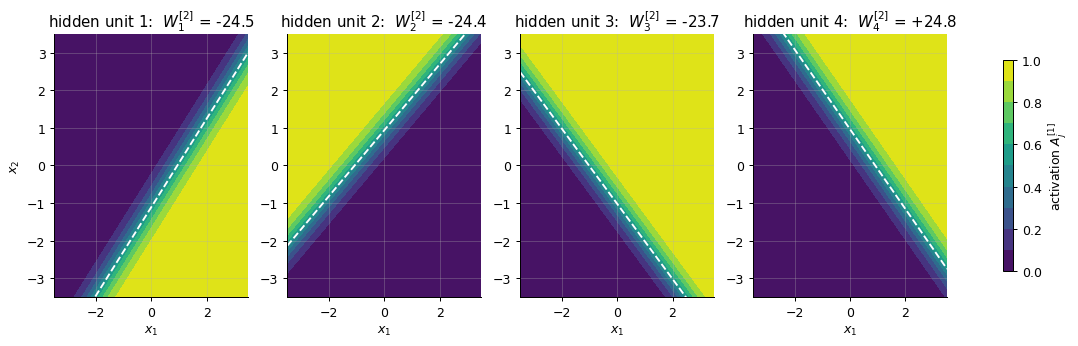

In [15]:
g1, g2 = np.meshgrid(np.linspace(-3.5, 3.5, 200), np.linspace(-3.5, 3.5, 200))
G = np.c_[g1.ravel(), g2.ravel()]
mlp.forward(G)
H = mlp.A1                                   # hidden activations on the grid, shape (40000, 4)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for j, ax in enumerate(axes):
    im = ax.contourf(g1, g2, H[:, j].reshape(g1.shape), levels=np.linspace(0, 1, 11), cmap="viridis")
    w1, w2, b = mlp.weights1[0, j], mlp.weights1[1, j], mlp.bias1[0, j]
    xs = np.linspace(-3.5, 3.5, 2)
    if abs(w2) > 1e-8:
        ax.plot(xs, -(w1 * xs + b) / w2, "w--", lw=1.5)
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.set_title(f"hidden unit {j + 1}:  $W^{{[2]}}_{j + 1}$ = {mlp.weights2[j, 0]:+.1f}")
    ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
fig.colorbar(im, ax=axes, shrink=0.8, label="activation $A^{[1]}_j$")
plt.show()

Each hidden unit has learned a **line**, and the four lines come in two pairs of parallel diagonals: two along $x_1 - x_2 = \text{const}$ and two along $x_1 + x_2 = \text{const}$. So the hidden layer measures how far a point is from each diagonal. This is the network's own version of the identity

$$
x_1 x_2 > 0 \iff |x_1 + x_2| > |x_1 - x_2| ,
$$

since $(x_1 + x_2)^2 - (x_1 - x_2)^2 = 4 x_1 x_2$. The output layer is a logistic regression on these four soft half-planes, with large positive and negative weights, and their combination reproduces the four quadrants. Your picture may differ if you change the seed: many different sets of lines solve the task. Nobody told the network to use these features: gradient descent found them because they reduce the loss. This is what "learning the features" means.

## 11. Experiments

### 11.1 Width: how many hidden units are needed?

We train networks with 1, 2, 3, 4, 8 and 16 hidden units (same data, same settings, 2000 epochs).

hidden units  parameters  train acc  val acc


           1           5      0.649    0.636


           2           9      0.752    0.742


           3          13      0.795    0.756


           4          17      0.983    0.982


           8          33      0.985    0.960


          16          65      0.992    0.964


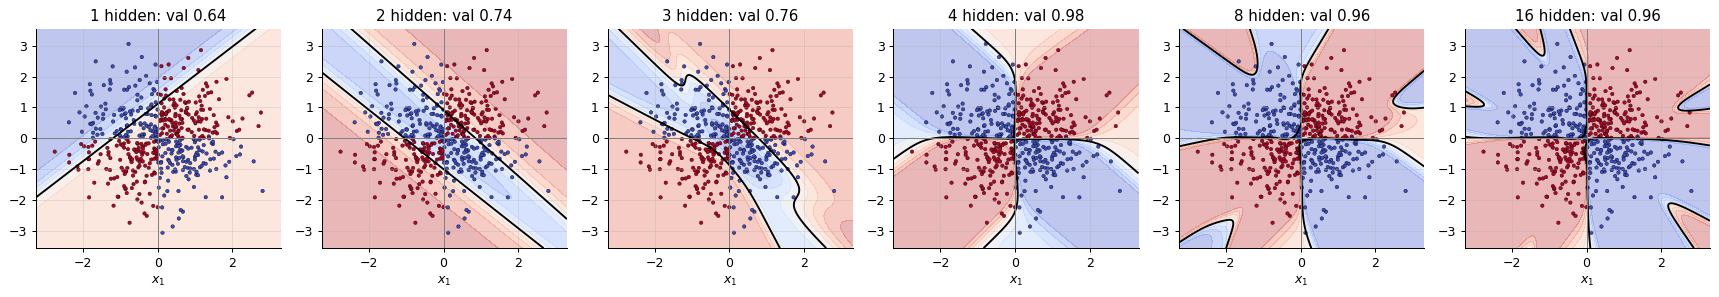

In [16]:
widths = [1, 2, 3, 4, 8, 16]
fig, axes = plt.subplots(1, len(widths), figsize=(3.2 * len(widths), 3.4))
print(f"{'hidden units':>12}{'parameters':>12}{'train acc':>11}{'val acc':>9}")
for ax, h in zip(axes, widths):
    net = SimpleMLP(2, h, 1, learning_rate=0.3, seed=0)
    net.train(X, y, epochs=2000, batch_size=32)
    n_params = 2 * h + h + h + 1
    tr, va = np.mean(net.predict(X) == y), np.mean(net.predict(X_val) == y_val)
    print(f"{h:>12}{n_params:>12}{tr:>11.3f}{va:>9.3f}")
    plot_boundary(ax, net.predict_proba, X_val, y_val, f"{h} hidden: val {va:.2f}")
    ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Interpretation.**
- **1 unit**: the output is a monotone function of a single line, so the boundary is still a line. No better than logistic regression.
- **2 units**: two parallel lines, so the network can only cut out a **band**. That captures part of the pattern and misses the rest.
- **3 units**: the boundary bends, but three soft half-planes are not enough to build all four quadrants.
- **4 units or more**: the task is solved. This matches the identity of section 10. With ReLU units it can even be written exactly: $|t| = \text{ReLU}(t) + \text{ReLU}(-t)$, so $|x_1 + x_2| - |x_1 - x_2|$ needs exactly four ReLU units.
- **8 and 16 units**: the training accuracy keeps rising, but the validation accuracy is a little **lower** than with 4 units. The extra capacity is spent on details of this particular training sample: a first, mild sign of **overfitting**. Look also at the corners: far from the data the wider networks draw **islands** of the wrong class. Nothing in the training set constrains the function there, so a network's extrapolation outside the data should never be trusted.

### 11.2 Learning rate

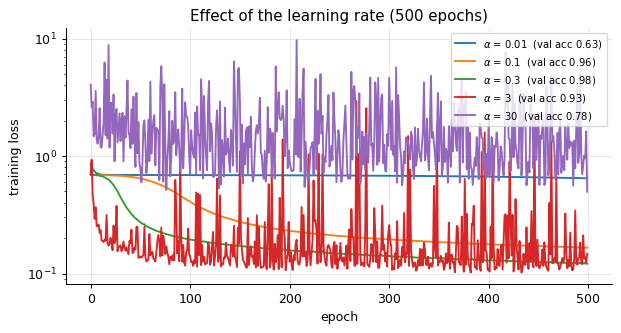

In [17]:
lrs = [0.01, 0.1, 0.3, 3.0, 30.0]
fig, ax = plt.subplots(figsize=(7, 3.8))
for lr in lrs:
    net = SimpleMLP(2, 4, 1, learning_rate=lr, seed=0)
    h = net.train(X, y, epochs=500, batch_size=32)
    ax.plot(h["train"], label=rf"$\alpha$ = {lr:g}  (val acc {np.mean(net.predict(X_val) == y_val):.2f})")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("training loss"); ax.legend(fontsize=8)
ax.set_title("Effect of the learning rate (500 epochs)")
plt.tight_layout(); plt.show()

Same story as in linear regression, except that there is no formula for the largest safe step because the loss is not quadratic:
- **Too small** ($\alpha = 0.01$): it barely moves away from $\log 2$ in 500 epochs.
- **Reasonable** ($0.1$ to $0.3$): the loss falls steadily. The larger value is faster.
- **Too large**: with $\alpha = 3$ the loss drops fast but keeps jumping up whenever a step overshoots. With $\alpha = 30$ it never settles at all. Huge steps also make the weights very large, which pushes the sigmoids into saturation where the gradient vanishes.

In practice you try values on a logarithmic grid ($10^{-3}, 10^{-2}, \dots$) and keep the one with the best validation loss.

### 11.3 Random restarts: the loss is not convex

In linear and logistic regression the loss is convex, so every starting point leads to the same minimum. Here we train the same 4-unit network from five different random initialisations.

seed  final train loss  val acc


   0            0.0827    0.982


   1            0.0831    0.980


   2            0.2050    0.874


   3            0.1785    0.920


   4            0.0775    0.968


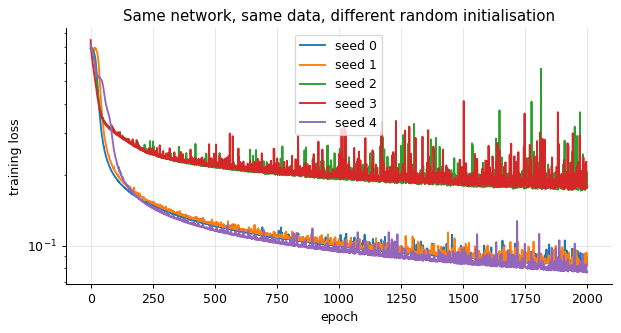

In [18]:
fig, ax = plt.subplots(figsize=(7, 3.8))
print(f"{'seed':>4}{'final train loss':>18}{'val acc':>9}")
for seed in range(5):
    net = SimpleMLP(2, 4, 1, learning_rate=0.3, seed=seed)
    h = net.train(X, y, epochs=2000, batch_size=32)
    va = np.mean(net.predict(X_val) == y_val)
    print(f"{seed:>4}{h['train'][-1]:>18.4f}{va:>9.3f}")
    ax.plot(h["train"], label=f"seed {seed}")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("training loss"); ax.legend()
ax.set_title("Same network, same data, different random initialisation")
plt.tight_layout(); plt.show()

Some runs reach a low loss and others get stuck at a clearly worse value: they have converged to different **local minima** (or are stuck on a very flat region). This is the price of non-convexity. Two practical remedies:
- **Make the network wider.** With more hidden units than strictly needed there are many good solutions, and gradient descent finds one much more reliably. This is one reason why real networks are heavily over-parameterised.
- **Use better optimisers and initialisations** (Adam, He/Xavier initialisation), covered in the PyTorch lab and in the notes.

### 11.4 Initialisation: why not start from zero?

In [19]:
net0 = SimpleMLP(2, 4, 1, learning_rate=0.3, init="zeros")
net0.train(X, y, epochs=500, batch_size=32)
print("W1 after training with zero initialisation (one column per hidden unit):")
print(net0.weights1.round(4))
print("b1:", net0.bias1.round(4))
print("W2:", net0.weights2.ravel().round(4))
print(f"val accuracy: {np.mean(net0.predict(X_val) == y_val):.3f}")

W1 after training with zero initialisation (one column per hidden unit):
[[-2.8757 -2.8757 -2.8757 -2.8757]
 [-3.0727 -3.0727 -3.0727 -3.0727]]
b1: [[-5.074 -5.074 -5.074 -5.074]]
W2: [0.8185 0.8185 0.8185 0.8185]
val accuracy: 0.598


The weights did change, but the four columns of $\mathbf{W}^{[1]}$ are **identical**, and so are the four output weights. The four hidden units are copies of each other, and the validation accuracy is about that of the 1-unit network in section 11.1. Why:
1. At the start every hidden unit outputs $\sigma(0) = 0.5$ for every input.
2. With $\mathbf{W}^{[2]} = \mathbf{0}$, $\boldsymbol{\delta}^{[1]} = (\boldsymbol{\delta}^{[2]}\mathbf{W}^{[2]\top}) \odot \sigma'(\mathbf{Z}^{[1]}) = \mathbf{0}$, so in the first step the first layer gets no gradient.
3. $\mathbf{W}^{[2]}$ does receive a gradient, but it is the same for every hidden unit, because they all have the same activation. So after one step the output weights are non-zero but equal.
4. From then on column $j$ of $\mathbf{W}^{[1]}$ gets the gradient $\mathbf{X}^\top\boldsymbol{\delta}^{[1]}_{:,j}$, and $\boldsymbol{\delta}^{[1]}_{:,j}$ is the same for every $j$ because the units have the same weights. Identical units get identical updates and never become different.

The same happens whenever the units start as exact copies, zero or not: the network behaves like a network with **one** hidden unit. Random initialisation breaks this **symmetry**. How large the random weights should be (Xavier and He initialisation) is derived in the notes.

## 12. Summary

- A neuron is a logistic regression. A hidden layer is several of them in parallel, and it computes **learned features** of the input.
- Forward pass: $\mathbf{Z}^{[l]} = \mathbf{A}^{[l-1]}\mathbf{W}^{[l]} + \mathbf{b}^{[l]}$, $\mathbf{A}^{[l]} = g(\mathbf{Z}^{[l]})$. Without a non-linear $g$, any number of layers collapses into one linear model.
- Loss for binary classification: binary cross-entropy, which is the negative log-likelihood of a Bernoulli model.
- Backpropagation is the chain rule applied from the loss backwards: $\boldsymbol{\delta}^{[2]} = \frac{1}{m}(\mathbf{A}^{[2]} - \mathbf{y})$, $\boldsymbol{\delta}^{[l]} = (\boldsymbol{\delta}^{[l+1]}\mathbf{W}^{[l+1]\top}) \odot g'(\mathbf{Z}^{[l]})$, $\partial J / \partial \mathbf{W}^{[l]} = \mathbf{A}^{[l-1]\top}\boldsymbol{\delta}^{[l]}$.
- Every gradient has the shape of its parameter. Check the values with finite differences.
- Training loop: shuffle, then for each mini-batch do forward, backward, update. Watch training **and** validation loss.
- The loss is non-convex: results depend on the initialisation, and the loss can plateau. Wider networks and good optimisers help.
- Initialise weights randomly to break the symmetry between hidden units.

Next lab: the same network in PyTorch, where the backward pass is computed automatically.

## Exercises

Try each one before opening the answer.

1. **XOR with four points.** Section 1 proved that the four points $(\pm1, \pm1)$ are not linearly separable. Find by hand a network with **2** hidden threshold units ($g(z) = \mathbb{1}[z > 0]$) that classifies these four points correctly.
2. **Weight initialisation.** What happens if all weights are initialised to the same non-zero value $c$? Would the network still be stuck?
3. **Vanishing gradients.** Using $\sigma' \le 1/4$, bound how much the error $\boldsymbol{\delta}$ can shrink after going back through $L$ sigmoid layers. Why does ReLU help?
4. **Mini-batch size.** Compare batch size 1 (pure stochastic gradient descent), 32 and 1000 (full batch). Use the `train` method with the same number of epochs and compare speed and final loss. Explain what you see.
5. **Change the hidden activation.** Replace the hidden sigmoid by $\tanh$. Which lines of `forward` and `compute_gradients` change? Does it train faster?
6. **Two hidden layers.** Write the forward and backward equations for a network $2 \to 4 \to 4 \to 1$.

<details>
<summary><b>Answers</b></summary>

**1.** Let $h_1 = \mathbb{1}[x_1 + x_2 - 1 > 0]$, which is 1 only at $(1, 1)$, and $h_2 = \mathbb{1}[-x_1 - x_2 - 1 > 0]$, which is 1 only at $(-1, -1)$. The output $\hat{y} = \mathbb{1}[h_1 + h_2 - 0.5 > 0]$ is an OR of the two, so it equals 1 exactly at $(1,1)$ and $(-1,-1)$. For four points two hidden units are enough. For the continuous data section 11.1 showed that more are needed.

**2.** They are still stuck. All hidden units compute the same function, get the same gradient and receive the same update, so they stay equal forever. The network behaves like one with a single hidden unit. Any initialisation where units are exact copies of each other has this problem. That is why the weights must be **random**.

**3.** Going back through one layer multiplies the error by $\mathbf{W}^{[l+1]\top}$ and by $\sigma'(\mathbf{Z}^{[l]}) \le 1/4$. Ignoring the weights, after $L$ layers the error is at most $(1/4)^L$ of its size at the output: $10^{-6}$ for $L = 10$. The first layers then learn almost nothing. ReLU has derivative exactly 1 for active units, so the factor $g'$ does not shrink the signal. Good initialisation (He) keeps the weight factors close to 1 as well.

**4.** With batch size 1 there are 1000 updates per epoch: each epoch is slow in Python, but the loss drops in very few epochs, with a lot of noise. With the full batch there is one exact but expensive update per epoch, so progress per epoch is slow. Batch 32 is the usual compromise: vectorised and cheap per step, with many steps per epoch and moderate noise. Note that the number of updates, not the number of epochs, is what drives progress.

**5.** Only the activation and its derivative change: `A1 = np.tanh(Z1)` in `forward`, and `delta1 = dA1 * (1 - self.A1 ** 2)` in `compute_gradients`. The output stays a sigmoid because it must be a probability. $\tanh$ is centred at 0 and has maximum slope 1 instead of 1/4, so it usually trains faster.

**6.** Forward: $\mathbf{Z}^{[1]} = \mathbf{X}\mathbf{W}^{[1]} + \mathbf{b}^{[1]}$, $\mathbf{A}^{[1]} = g(\mathbf{Z}^{[1]})$, $\mathbf{Z}^{[2]} = \mathbf{A}^{[1]}\mathbf{W}^{[2]} + \mathbf{b}^{[2]}$, $\mathbf{A}^{[2]} = g(\mathbf{Z}^{[2]})$, $\mathbf{Z}^{[3]} = \mathbf{A}^{[2]}\mathbf{W}^{[3]} + \mathbf{b}^{[3]}$, $\hat{\mathbf{y}} = \sigma(\mathbf{Z}^{[3]})$. Backward: $\boldsymbol{\delta}^{[3]} = \frac{1}{m}(\hat{\mathbf{y}} - \mathbf{y})$, $\boldsymbol{\delta}^{[2]} = (\boldsymbol{\delta}^{[3]}\mathbf{W}^{[3]\top}) \odot g'(\mathbf{Z}^{[2]})$, $\boldsymbol{\delta}^{[1]} = (\boldsymbol{\delta}^{[2]}\mathbf{W}^{[2]\top}) \odot g'(\mathbf{Z}^{[1]})$. For $l = 1, 2, 3$: $\partial J/\partial \mathbf{W}^{[l]} = \mathbf{A}^{[l-1]\top}\boldsymbol{\delta}^{[l]}$ and $\partial J/\partial \mathbf{b}^{[l]}$ = sum of the rows of $\boldsymbol{\delta}^{[l]}$, with $\mathbf{A}^{[0]} = \mathbf{X}$.

</details>